In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import jsonlines

import google.generativeai as genai
import google.ai.generativelanguage as glm

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import asyncio
import nest_asyncio
from asynciolimiter import Limiter
from tqdm.asyncio import tqdm_asyncio

from dotenv import load_dotenv
from tqdm.auto import tqdm

nest_asyncio.apply()
load_dotenv()

True

In [2]:
genai.configure(api_key=os.getenv('GOOGLE_AI_STUDIO_API_KEY'))

In [3]:
for m in genai.list_models():
  if 'embedContent' in m.supported_generation_methods:
    print(m.name)

models/embedding-001
models/text-embedding-004


In [76]:
df = pd.read_json(os.path.join('..', 'data', 'info_collection', 'preprocess_input.jsonl'), lines=True, orient='records')
df

,id,problem,solution,prompt,concept,chapter_name
0,Exp0000,Write the next three natural numbers after 10999.,"10,999+1 = 11,000\n11,000 + 1 = 11,001\n11,001...",<math_problem>\nWrite the next three natural n...,Concept for Natural Numbers,Whole Numbers
1,Exp0001,Write the three whole numbers occurring just b...,Three whole numbers occurring just before 1000...,<math_problem>\nWrite the three whole numbers ...,Concept for Whole Numbers,Whole Numbers
2,Exp0002,Which is the smallest whole number?,0 (zero) is the smallest whole number. All the...,<math_problem>\nWhich is the smallest whole nu...,Concept for Whole Numbers,Whole Numbers
3,Exp0003,How many whole numbers are there between 32 an...,Whole numbers between 32 and 53 = 20 (53 − 32 ...,<math_problem>\nHow many whole numbers are the...,Concept for Whole Numbers,Whole Numbers
4,Exp0004,Write the successor of 2440701.,The successor of 2440701 is\n2440701 + 1 = 244...,<math_problem>\nWrite the successor of 2440701...,Successor and Predecessor of Whole Number,Whole Numbers
...,...,...,...,...,...,...
4321,Exp4321,If each element of a second order determinant ...,The total number of determinants of second ord...,<math_problem>\nIf each element of a second or...,Independent Events,Probability
4322,Exp4322,An electronic assembly consists of two subsyst...,Let the event in which A fails and B fails be ...,<math_problem>\nAn electronic assembly consist...,Properties of Conditional Probability,Probability
4323,Exp4323,If A and B are two events such that P (A) ≠ 0 ...,"P (A) ≠ 0 and P(B|A) = 1\n\nThus, the correct ...",<math_problem>\nIf A and B are two events such...,Properties of Conditional Probability,Probability
4324,Exp4324,"If P (A|B) > P (A), then which of the followin...","\nThus, the correct answer is C.","<math_problem>\nIf P (A|B) > P (A), then which...",Properties of Conditional Probability,Probability


In [77]:
df.dropna(subset=['problem'])

,id,problem,solution,prompt,concept,chapter_name
0,Exp0000,Write the next three natural numbers after 10999.,"10,999+1 = 11,000\n11,000 + 1 = 11,001\n11,001...",<math_problem>\nWrite the next three natural n...,Concept for Natural Numbers,Whole Numbers
1,Exp0001,Write the three whole numbers occurring just b...,Three whole numbers occurring just before 1000...,<math_problem>\nWrite the three whole numbers ...,Concept for Whole Numbers,Whole Numbers
2,Exp0002,Which is the smallest whole number?,0 (zero) is the smallest whole number. All the...,<math_problem>\nWhich is the smallest whole nu...,Concept for Whole Numbers,Whole Numbers
3,Exp0003,How many whole numbers are there between 32 an...,Whole numbers between 32 and 53 = 20 (53 − 32 ...,<math_problem>\nHow many whole numbers are the...,Concept for Whole Numbers,Whole Numbers
4,Exp0004,Write the successor of 2440701.,The successor of 2440701 is\n2440701 + 1 = 244...,<math_problem>\nWrite the successor of 2440701...,Successor and Predecessor of Whole Number,Whole Numbers
...,...,...,...,...,...,...
4321,Exp4321,If each element of a second order determinant ...,The total number of determinants of second ord...,<math_problem>\nIf each element of a second or...,Independent Events,Probability
4322,Exp4322,An electronic assembly consists of two subsyst...,Let the event in which A fails and B fails be ...,<math_problem>\nAn electronic assembly consist...,Properties of Conditional Probability,Probability
4323,Exp4323,If A and B are two events such that P (A) ≠ 0 ...,"P (A) ≠ 0 and P(B|A) = 1\n\nThus, the correct ...",<math_problem>\nIf A and B are two events such...,Properties of Conditional Probability,Probability
4324,Exp4324,"If P (A|B) > P (A), then which of the followin...","\nThus, the correct answer is C.","<math_problem>\nIf P (A|B) > P (A), then which...",Properties of Conditional Probability,Probability


In [6]:
# from google.api_core import retry
# from tqdm.auto import tqdm
# tqdm.pandas()

# def make_embed_text_fn(model):

#   @retry.Retry(timeout=300.0)
#   def embed_fn(text: str) -> list[float]:
#     # Set the task_type to CLUSTERING.
#     embedding = genai.embed_content(model=model,
#                                     content=text,
#                                     task_type="clustering")
#     return embedding["embedding"]

#   return embed_fn

# def create_embeddings(df):
#   model = 'models/embedding-001'
#   df['problem_Embeddings'] = df['problem'].progress_apply(make_embed_text_fn(model))
#   df['solution_Embeddings'] = df['solution'].progress_apply(make_embed_text_fn(model))
#   return df

# df_train = create_embeddings(df)

In [7]:
embeddings = await genai.embed_content_async(model='models/text-embedding-004', content=df.problem[0], output_dimensionality=768)
len(embeddings['embedding'])

768

In [8]:
async def get_async_embeddings(
        df:pd.DataFrame,
        model_name:str,
        interim_results_df:pd.DataFrame,
        interim_fname:str,
        save_every:int=100,
        rpm:int=200,
        max_concurrent_tasks:int=60,
        col_names:list=['problem', 'solution'],
    ):

    # Setup Limiter
    rate_limiter = Limiter(rpm // 60, max_burst=max_concurrent_tasks)

    ## Async Function Call to Model ##
    async def gemini_async_call(text:str, idx:int, id:str, col_name:str):
        # with semaphore:
        await rate_limiter.wait()
        try:
            embeddings = await genai.embed_content_async(model=model_name, content=text, task_type="clustering")
            return embeddings['embedding'], int(idx), id, col_name
            # return await genai.embed_content_async(model=model_name, content=text, output_dimensionality=768)['embedding'], int(idx), id, col_name
        except Exception:
            return None, int(idx), id, col_name

    ## Main Function ##
    tasks = []
    for col_name in col_names:
        for idx in tqdm(df[df[col_name].notna()].index, desc=f'Creating Tasks for {col_name} Embeddings'):

            if idx in interim_results_df[interim_results_df['col'] == col_name].id.values:
                continue
            
            input_prompt = df[col_name][idx]
            exp_id = df['id'][idx]
            tasks.append(asyncio.create_task(gemini_async_call(input_prompt, idx, exp_id, col_name)))

    print(f'{len(tasks)} Tasks Created')
    counter = 0
    safety_counter = 0
    interim_results = []
    for done in tqdm_asyncio.as_completed(tasks, ncols=100, desc="Waiting for Tasks:", leave=True):

        result, idx, exp_id, col  = await done
        idx: int
        counter += 1

        try:
            interim_results.append({
                'id': idx,
                'exp_id': exp_id,
                'col': col,
                'embedding': result,
            })
            
        except Exception:
            safety_counter += 1
            interim_results.append({
                'id': idx,
                'exp_id': exp_id,
                'col': col,
                'embedding': None,
            })

        # Save to file
        if counter % save_every == 0:
            with jsonlines.open(interim_fname, 'a') as writer:
                writer.write_all(interim_results)
            interim_results = []

    print(f"Number of Safety Blocks: {safety_counter}")
    
    with jsonlines.open(interim_fname, 'a') as writer:
        writer.write_all(interim_results)


In [9]:
# # interim_fname = f'interim_results_Preprocessing_input_data_{pd.to_datetime("now").strftime("%Y%m%d_%H%M%S")}.jsonl'
# interim_fname = 'interim_results_Preprocessing_input_embeddings.jsonl'
# print(f"Interim Results File: {interim_fname}")

# if not os.path.exists(interim_fname):
#     with jsonlines.open(interim_fname, 'w') as writer:
#         writer.write_all([])

In [10]:
interim_fname = 'interim_results_Preprocessing_input_embeddings.jsonl'
with jsonlines.open(interim_fname, 'r') as reader:
    interim_results_df = pd.DataFrame(reader)

if len(interim_results_df) == 0:
    interim_results_df = pd.DataFrame(columns=['id', 'exp_id', 'col', 'embedding'])

In [11]:
# intermedate_df = asyncio.run(get_raw_output_from_llm_v2(chucked_df, interim_results_df))
asyncio.run(
    get_async_embeddings(
        df=df,
        model_name='models/embedding-001',
        interim_results_df=interim_results_df,
        interim_fname=interim_fname,
        save_every=10,
        rpm=1200,
        max_concurrent_tasks=512,
        col_names=['problem', 'solution']
    )
)

Creating Tasks for problem Embeddings:   0%|          | 0/4326 [00:00<?, ?it/s]

Creating Tasks for solution Embeddings:   0%|          | 0/4326 [00:00<?, ?it/s]

8652 Tasks Created


Waiting for Tasks:: 100%|███████████████████████████████████████| 8652/8652 [07:13<00:00, 19.98it/s]


Number of Safety Blocks: 0


In [78]:
new_df = pd.read_json(interim_fname, lines=True, orient='records')
new_df

,id,exp_id,col,embedding
0,0,Exp0000,problem,"[-0.013325223, -0.019847063, -0.01460488200000..."
1,2,Exp0002,problem,"[-0.02417113, -0.043132477, -0.05889094, -0.08..."
2,3,Exp0003,problem,"[0.006177559500000001, -0.040292304, -0.055946..."
3,1,Exp0001,problem,"[-0.0012671729, -0.06804299999999999, -0.01577..."
4,4,Exp0004,problem,"[0.049222260000000004, -0.057859223, -0.046411..."
...,...,...,...,...
8647,4321,Exp4321,solution,"[-0.053980596000000006, -0.048657175000000004,..."
8648,4322,Exp4322,solution,"[-0.011160274000000001, -0.048090473, -0.01382..."
8649,4323,Exp4323,solution,"[0.009474321, -0.07166414, 0.00964222, -0.0610..."
8650,4324,Exp4324,solution,"[0.014905821500000001, -0.05192171, -0.0350613..."


In [79]:
type(new_df.embedding[0])

list

In [80]:
df['problem_Embeddings'] = None
df['solution_Embeddings'] = None
df['problem_Embeddings'] = df['problem_Embeddings'].astype(object)
df['solution_Embeddings'] = df['solution_Embeddings'].astype(object)

for _, row in tqdm(new_df.iterrows(), total=len(new_df)):
    col = row['col']
    emb = row['embedding']
    exp_id = row['exp_id']
    idx = df[df['id'] == exp_id].index.values[0]

    df.at[idx, f'{col}_Embeddings'] = emb

  0%|          | 0/8652 [00:00<?, ?it/s]

In [81]:
df

,id,problem,solution,prompt,concept,chapter_name,problem_Embeddings,solution_Embeddings
0,Exp0000,Write the next three natural numbers after 10999.,"10,999+1 = 11,000\n11,000 + 1 = 11,001\n11,001...",<math_problem>\nWrite the next three natural n...,Concept for Natural Numbers,Whole Numbers,"[-0.013325223, -0.019847063, -0.01460488200000...","[-0.045395765000000005, 0.013073164, -0.003491..."
1,Exp0001,Write the three whole numbers occurring just b...,Three whole numbers occurring just before 1000...,<math_problem>\nWrite the three whole numbers ...,Concept for Whole Numbers,Whole Numbers,"[-0.0012671729, -0.06804299999999999, -0.01577...","[-0.028765762, -0.022315439000000003, -0.02681..."
2,Exp0002,Which is the smallest whole number?,0 (zero) is the smallest whole number. All the...,<math_problem>\nWhich is the smallest whole nu...,Concept for Whole Numbers,Whole Numbers,"[-0.02417113, -0.043132477, -0.05889094, -0.08...","[-0.020093305000000002, -0.026633421, -0.01205..."
3,Exp0003,How many whole numbers are there between 32 an...,Whole numbers between 32 and 53 = 20 (53 − 32 ...,<math_problem>\nHow many whole numbers are the...,Concept for Whole Numbers,Whole Numbers,"[0.006177559500000001, -0.040292304, -0.055946...","[-0.004487335, -0.021730514000000003, -0.02759..."
4,Exp0004,Write the successor of 2440701.,The successor of 2440701 is\n2440701 + 1 = 244...,<math_problem>\nWrite the successor of 2440701...,Successor and Predecessor of Whole Number,Whole Numbers,"[0.049222260000000004, -0.057859223, -0.046411...","[0.02767218, -0.04029168, -0.049827874, -0.057..."
...,...,...,...,...,...,...,...,...
4321,Exp4321,If each element of a second order determinant ...,The total number of determinants of second ord...,<math_problem>\nIf each element of a second or...,Independent Events,Probability,"[-0.049116440000000004, -0.030459732000000003,...","[-0.053980596000000006, -0.048657175000000004,..."
4322,Exp4322,An electronic assembly consists of two subsyst...,Let the event in which A fails and B fails be ...,<math_problem>\nAn electronic assembly consist...,Properties of Conditional Probability,Probability,"[0.007747334000000001, -0.052650116000000004, ...","[-0.011160274000000001, -0.048090473, -0.01382..."
4323,Exp4323,If A and B are two events such that P (A) ≠ 0 ...,"P (A) ≠ 0 and P(B|A) = 1\n\nThus, the correct ...",<math_problem>\nIf A and B are two events such...,Properties of Conditional Probability,Probability,"[-0.029212316000000002, -0.0520235, 0.01386870...","[0.009474321, -0.07166414, 0.00964222, -0.0610..."
4324,Exp4324,"If P (A|B) > P (A), then which of the followin...","\nThus, the correct answer is C.","<math_problem>\nIf P (A|B) > P (A), then which...",Properties of Conditional Probability,Probability,"[0.01799076, -0.05181035, 0.0012903608, -0.035...","[0.014905821500000001, -0.05192171, -0.0350613..."


In [82]:
df.dropna(inplace=True)

In [83]:
# Convert df_train['Embeddings'] Pandas series to a np.array of float32
X = df['problem_Embeddings'].values


In [84]:
# Convert df_train['Embeddings'] Pandas series to a np.array of float32
X = np.array(df['problem_Embeddings'].to_list(), dtype=np.float32)
X.shape

(4324, 768)

In [85]:
tsne = TSNE(random_state=0, n_iter=1000)
tsne_results = tsne.fit_transform(X)

In [124]:
df_tsne = pd.DataFrame(tsne_results, columns=['TSNE1', 'TSNE2'])
df_tsne['concept'] = df['concept']
df_tsne['exp_id'] = df['id']
df_tsne

,TSNE1,TSNE2,concept,exp_id
0,-34.890072,16.300983,Concept for Natural Numbers,Exp0000
1,-34.935066,16.242981,Concept for Whole Numbers,Exp0001
2,-41.964520,0.353563,Concept for Whole Numbers,Exp0002
3,-43.313461,-12.664936,Concept for Whole Numbers,Exp0003
4,-32.919956,18.562939,Successor and Predecessor of Whole Number,Exp0004
...,...,...,...,...
4319,31.071737,0.074566,Conditional Probability,Exp4319
4320,-43.851612,-45.133522,Random Variables and Its Probability Distribut...,Exp4320
4321,-45.197823,-47.677784,Independent Events,Exp4321
4322,-43.880341,-48.581173,Properties of Conditional Probability,Exp4322


(-87.24231758117676, 91.39859046936036, -80.37901992797852, 92.41525955200196)

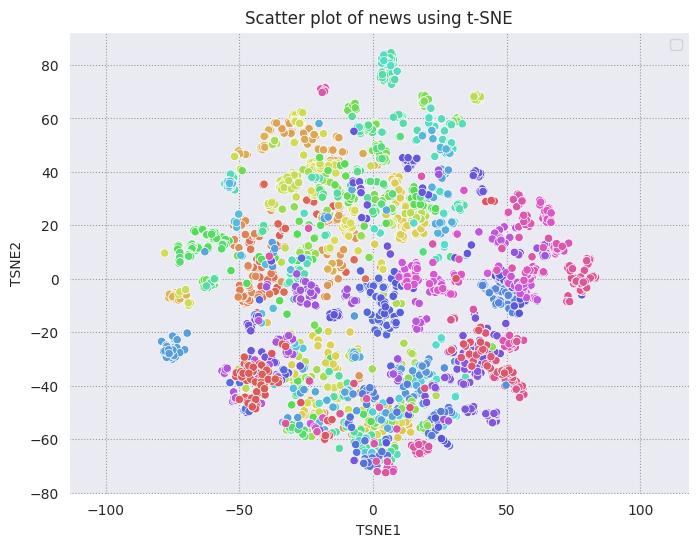

In [89]:
fig, ax = plt.subplots(figsize=(8,6)) # Set figsize
sns.set_style('darkgrid', {"grid.color": ".6", "grid.linestyle": ":"})
sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='concept', palette='hls')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title('Scatter plot of news using t-SNE')
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.legend([])
plt.axis('equal')

In [125]:
# Apply KMeans
kmeans_model = KMeans(n_clusters=100, random_state=1, n_init='auto').fit(X)
labels = kmeans_model.fit_predict(X)
df_tsne['Cluster'] = labels

(-87.24231758117676, 91.39859046936036, -80.37901992797852, 92.41525955200196)

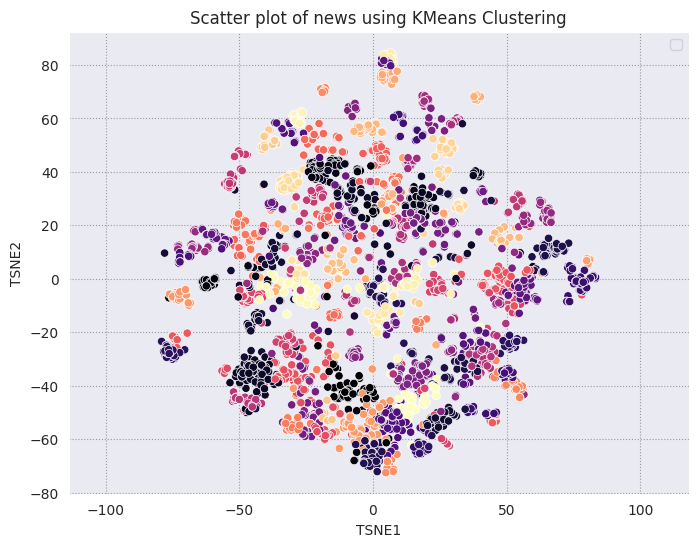

In [96]:
fig, ax = plt.subplots(figsize=(8,6)) # Set figsize
sns.set_style('darkgrid', {"grid.color": ".6", "grid.linestyle": ":"})
sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='Cluster', palette='magma')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title('Scatter plot of news using KMeans Clustering')
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.legend([])
plt.axis('equal')

In [115]:
def get_majority_cluster_per_group(df_tsne_cluster, class_names):
  class_clusters = dict()
  for c in class_names:
    # Get rows of dataframe that are equal to c
    rows = df_tsne_cluster.loc[df_tsne_cluster['concept'] == c]
    # Get majority value in Cluster column of the rows selected
    try:
        cluster = rows.Cluster.mode().values[0]
    except:
        print(f'No cluster for {c}')
        cluster = 0
    # Populate mapping dictionary
    class_clusters[c] = cluster
  return class_clusters

In [116]:
df_tsne.loc[df_tsne['concept'] == 'Concept for Whole Numbers'].Cluster.mode()

0    82
Name: Cluster, dtype: int32

In [117]:
classes = df_tsne['concept'].unique()
class_clusters = get_majority_cluster_per_group(df_tsne, classes)
# class_clusters

No cluster for nan


In [126]:
df_tsne[df_tsne['Cluster'] == 0]

,TSNE1,TSNE2,concept,exp_id,Cluster
194,-5.030984,-37.235874,Highest Common Factor,Exp0194,0
198,-9.241721,-44.728909,Lowest Common Multiple,Exp0198,0
205,-17.097591,-6.659579,Concept for Ordering of Integers,Exp0205,0
206,-17.108274,-6.651982,Concept for Ordering of Integers,Exp0206,0
208,-17.202124,-6.668559,Concept for Ordering of Integers,Exp0208,0
...,...,...,...,...,...
2674,5.851869,-59.782093,Areas of Sector and Segment of a Circle,Exp2674,0
2896,4.979687,-61.320530,Concept of Angle,Exp2896,0
3135,-7.055477,-67.974823,Various Forms of the Equation of a Line,Exp3135,0
4070,-7.068130,-39.106762,Formation of a Differential Equation Whose Gen...,Exp4070,0


In [130]:
df['problem'][194], df['problem'][198]

('Three boys step off together from the same spot. Their steps measure 63 cm, 70 cm, and 77 cm respectively. What is the minimum distance each should cover so that all can cover the distance in complete steps?',
 'The traffic lights at three different road crossings change after every 48 seconds, 72 seconds, and 108 seconds respectively. If they change simultaneously at 7 a.m., at what time will they change simultaneously again?')